In [ ]:
"""
Burst_simulation_run.ipynb
Lukasz Radzinski
Charite Neurophysics Group, Berlin
Script for modeling
sigma burst variability
"""

'\nBurst_modeling.ipynb\nLukasz Radzinski\nCharite Neurophysics Group, Berlin\nScript for modeling\nsigma burst variability\n'

In [2]:
import os
import meet
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sig
from BurstModel import BurstModel
import matplotlib.ticker as plticker


# set global parameters for plots
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['savefig.dpi'] = 600

2026-02-09 01:33:05.057137: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 01:33:05.077645: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# general settings

# select subject [S1-S5]
subject = 'S1'

additional_file_info = ''
additional_title_info = ''

data_input_folder = '../Data/cleaned_data'
results_output_folder = '../Results/burst_simulation_results'

additional_plot_title = ''

srate = 20000

meg_unit = 'B [fT]'
meg_asd_unit = '[fT/√Hz]'

In [4]:
data_input_folder = os.path.join(data_input_folder)
results_output_folder = os.path.join(results_output_folder, subject)

In [5]:
# add header to the plot
def plt_header(main_title='', use_suptitle = False, fontsize=12):

    title = subject+', MEG'+additional_title_info
    title += '\n'+main_title+additional_plot_title
    
    if(use_suptitle):
        plt.suptitle(title, fontsize=fontsize)
    else:
        plt.title(title, fontsize=fontsize)

In [6]:
# show and save the plot
def plt_show_save_fig(fig_name=None):

    if(fig_name):
        fig_name += '.png'
    else:
        plt_show_save_fig.counter += 1
        fig_name = subject+'_fig%02d.png' % plt_show_save_fig.counter

    print('--------------------\n'+fig_name)
    os.makedirs(results_output_folder, exist_ok=True)
    plt.savefig(os.path.join(results_output_folder, fig_name), bbox_inches='tight')
    plt.show()

plt_show_save_fig.counter = 0

In [7]:
# load MEG and marker data

meg_data_file = os.path.join(data_input_folder, subject+'.npy')
meg_stim_data = np.load(meg_data_file)

meg_data = meg_stim_data[0]
marker = meet.getMarker(meg_stim_data[-1])

In [8]:
# set bandpass frequency range adjusted for every subject
if(subject == 'S1' or subject == 'S2'):
    sigma_lfreq = 450
    sigma_rfreq = 850
elif(subject == 'S3' or  subject == 'S4' or subject == 'S5'):
    sigma_lfreq = 500
    sigma_rfreq = 900

# Hilbert transform
meg_data_hilb = sig.hilbert(meg_data)

# FIR filter
sigma_fir_coeffs = sig.firwin(303, [sigma_lfreq, sigma_rfreq], pass_zero=False, fs=srate)
meg_sigma_data_hilb = sig.filtfilt(sigma_fir_coeffs, 1.0, meg_data_hilb)

In [9]:
# set sigma burst time window adjusted for every subject

if(subject == 'S1'):
    burst_win_ms = [13, 33]
elif(subject == 'S2'):
    burst_win_ms = [13, 28]
elif(subject == 'S3'):
    burst_win_ms = [13, 28]
elif(subject == 'S4'):
    burst_win_ms = [13, 25]
elif(subject == 'S5'):
    burst_win_ms = [10, 30]

In [10]:
# extract trials

burst_win_samples = np.round(np.array(burst_win_ms)/1000.*srate).astype(int)
sigma_burst_trials = meet.epochEEG(meg_sigma_data_hilb, marker, burst_win_samples)
data_t_burst_ms = np.linspace(burst_win_ms[0], burst_win_ms[1], sigma_burst_trials.shape[-2]+1)[:-1]

medium_win_ms = [0, 80]
medium_win_samples = np.round(np.array(medium_win_ms)/1000.*srate).astype(int)
sigma_medium_trials = meet.epochEEG(meg_sigma_data_hilb, marker, medium_win_samples)
data_t_medium_ms = np.linspace(medium_win_ms[0], medium_win_ms[1], sigma_medium_trials.shape[-2]+1)[:-1]

In [11]:
# calculate indices in medium trials that correspond to the sigma burst time window
burst_mt_smpl = [np.nonzero(data_t_medium_ms == burst_win_ms[0])[0][0],
              np.nonzero(data_t_medium_ms == burst_win_ms[1])[0][0]]
burst_mt_smpl = np.array(burst_mt_smpl)

# set simulated burst offset position in relation to the recorded burst
sigma_sim_offset_ms = 30
burst_sim_mt_smpl = np.array(burst_mt_smpl)+sigma_sim_offset_ms*srate//1000
data_t_burst_sim_ms = data_t_burst_ms + sigma_sim_offset_ms

In [12]:
# calculate evoked response
# use Tukey window to taper the edges

evoked_response_raw = (sigma_burst_trials.mean(-1))
tukey_win = sig.windows.tukey(len(evoked_response_raw), 0.2)
evoked_response_tuk = evoked_response_raw * tukey_win
evoked_response = evoked_response_tuk

--------------------
Evoked response.png


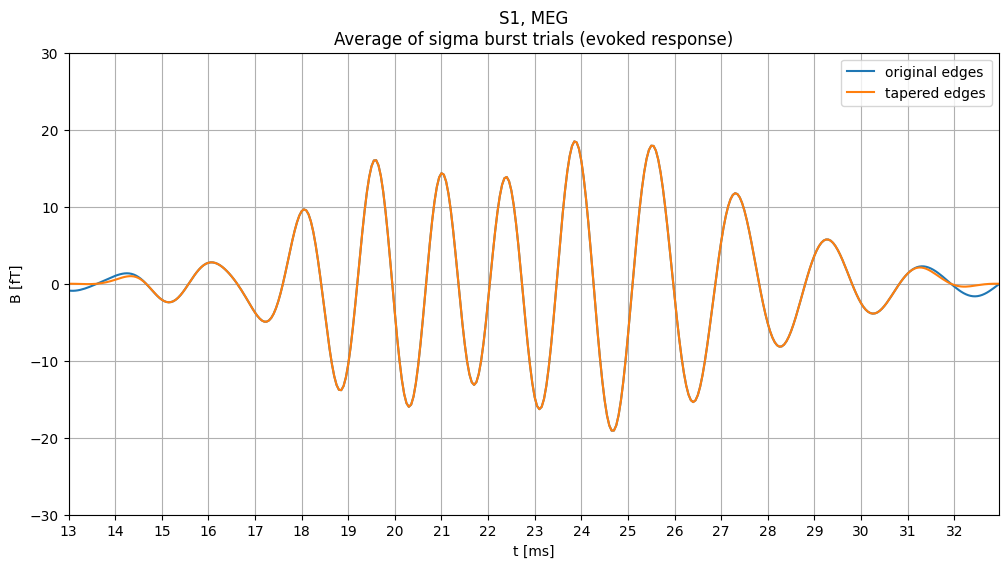

In [13]:
# plot sigma burst evoked response and edges tapered by Tukey window 

fig, ax = plt.subplots()
plt_header('Average of sigma burst trials (evoked response)')
data_y = evoked_response_raw.real
data_t = data_t_burst_ms
ax.plot(data_t, data_y, label='original edges')

data_y = evoked_response_tuk.real
ax.plot(data_t, data_y, label='tapered edges')

ax.set_xlabel('t [ms]')
ax.set_ylabel(meg_unit)
vmax=30
ax.set_ylim((-vmax,vmax))
ax.set_xlim((data_t[0], data_t[-1]))
ax.xaxis.set_major_locator(plticker.MultipleLocator(1))
ax.grid()
ax.legend()
plt_show_save_fig('Evoked response')

In [14]:
# plot loss function components
def plot_loss_results(burst_model, sigma_sim_medium_trials, filename=None):

    fig, axs = plt.subplots(2, 2, figsize=(16, 9))

    loss_result = burst_model.calculate_model_loss(sigma_sim_medium_trials, is_full_output=True)
    data_t = data_t_burst_ms

    for k in range(4):

        if(k == 0):
            i,j=0,0
            subtitle='A. Avg(trials)'
        elif(k == 1):
            i,j=0,1
            subtitle='B. StDev(trials)'
        elif(k == 2):
            i,j=1,0
            subtitle='C. Avg(Env(trials))'
        elif(k == 3):
            i,j=1,1
            subtitle='D. StDev(Env(trials))'

        data_y_phys_norm = loss_result[k][0]
        data_y_sim_norm = loss_result[k][1]
        data_y_phys_std = loss_result[k][2]
        data_y_phys_min = loss_result[k][3]

        loss = loss_result[-1][k]
        axs[i][j].set_title(subtitle+', MSE=%.3f' % loss, fontsize=14)
        axs[i][j].plot(data_t, data_y_phys_norm, linewidth=1, label='recorded burst')
        axs[i][j].plot(data_t, data_y_sim_norm, linewidth=1, label='simulated burst')
        axs[i][j].xaxis.set_major_locator(plticker.MultipleLocator(5))
        axs[i][j].set_xticks(np.sort(np.concatenate([axs[i][j].get_xticks(), burst_win_ms])))
        axs[i][j].set_xlim(burst_win_ms)
        axs[i][j].set_ylabel('normalized unit', fontsize=14)
        axs[i][j].tick_params(labelsize=12)
        axs[i][j].grid(linewidth=0.5)
        if(k==0 and subject=='S1'):
            axs[i][j].legend(loc='upper left', fontsize=14)
            axs[i][j].set_ylim(-4,4)
        elif(k==0):
            axs[i][j].legend(fontsize=14)
            axs[i][j].set_ylim(-4,4)
        else:
            axs[i][j].set_ylim(0,4)
        if(i==1):
            axs[i][j].set_xlabel('burst time [ms]', fontsize=14)

        axs2 = axs[i][j].twinx()
        physical_ticks = axs[i][j].get_yticks() * data_y_phys_std
        physical_ticks = physical_ticks + data_y_phys_min
        axs2.set_ylim((physical_ticks[0], physical_ticks[-1]))
        axs2.set_yticks(physical_ticks)
        axs2.yaxis.set_major_formatter(plticker.FormatStrFormatter('%4.1f'))
        axs2.set_ylabel(meg_unit, fontsize=14)
        axs2.tick_params(labelsize=12)

    if(filename):
        title = filename.split('/')[-1]
    else:
        title = subject
    plt.suptitle(title+'\nMeasures composing the loss function, combined loss=%.3f'
            % (loss_result[-1][-1]), fontsize=18)
    fig.tight_layout()
    plt_show_save_fig(filename)

In [15]:
# parameters to save in a file
df_out = pd.DataFrame({
    'subject':[],
    'fold':[],
    'opt_params':[],
    'div_steep':[],
    'div_pos':[],
    'ecavs':[],
    'eclvs':[],
    'lcavs':[],
    'lclvs':[],
    'train_loss':[],
    'test_loss':[]
})

(10, 0, 0, 0, 0, 0)
2.707575227085715
--------------------
f0/S1_f0_p0_div_curve.png


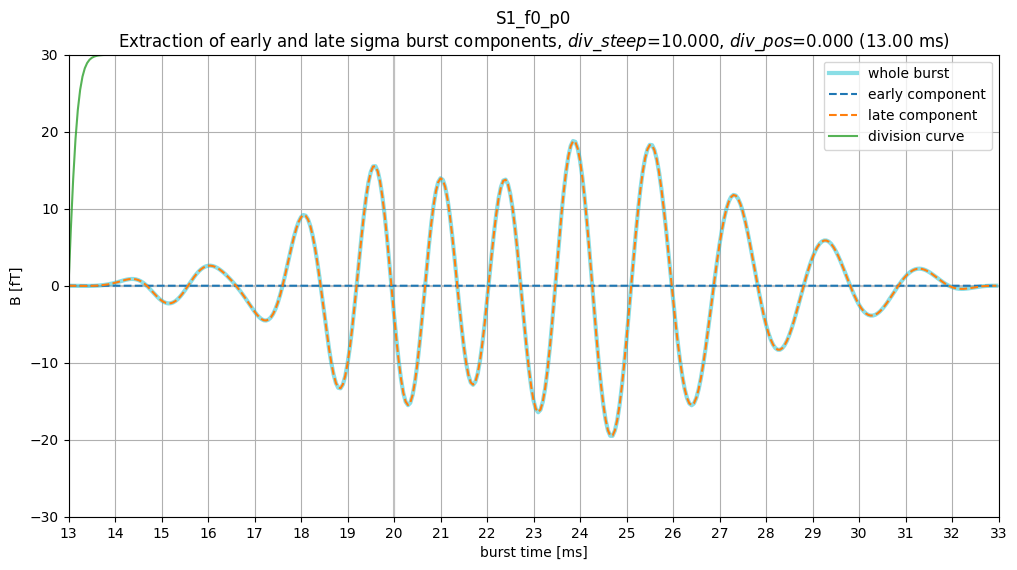

--------------------
f0/S1_f0_p0_train_set_loss.png


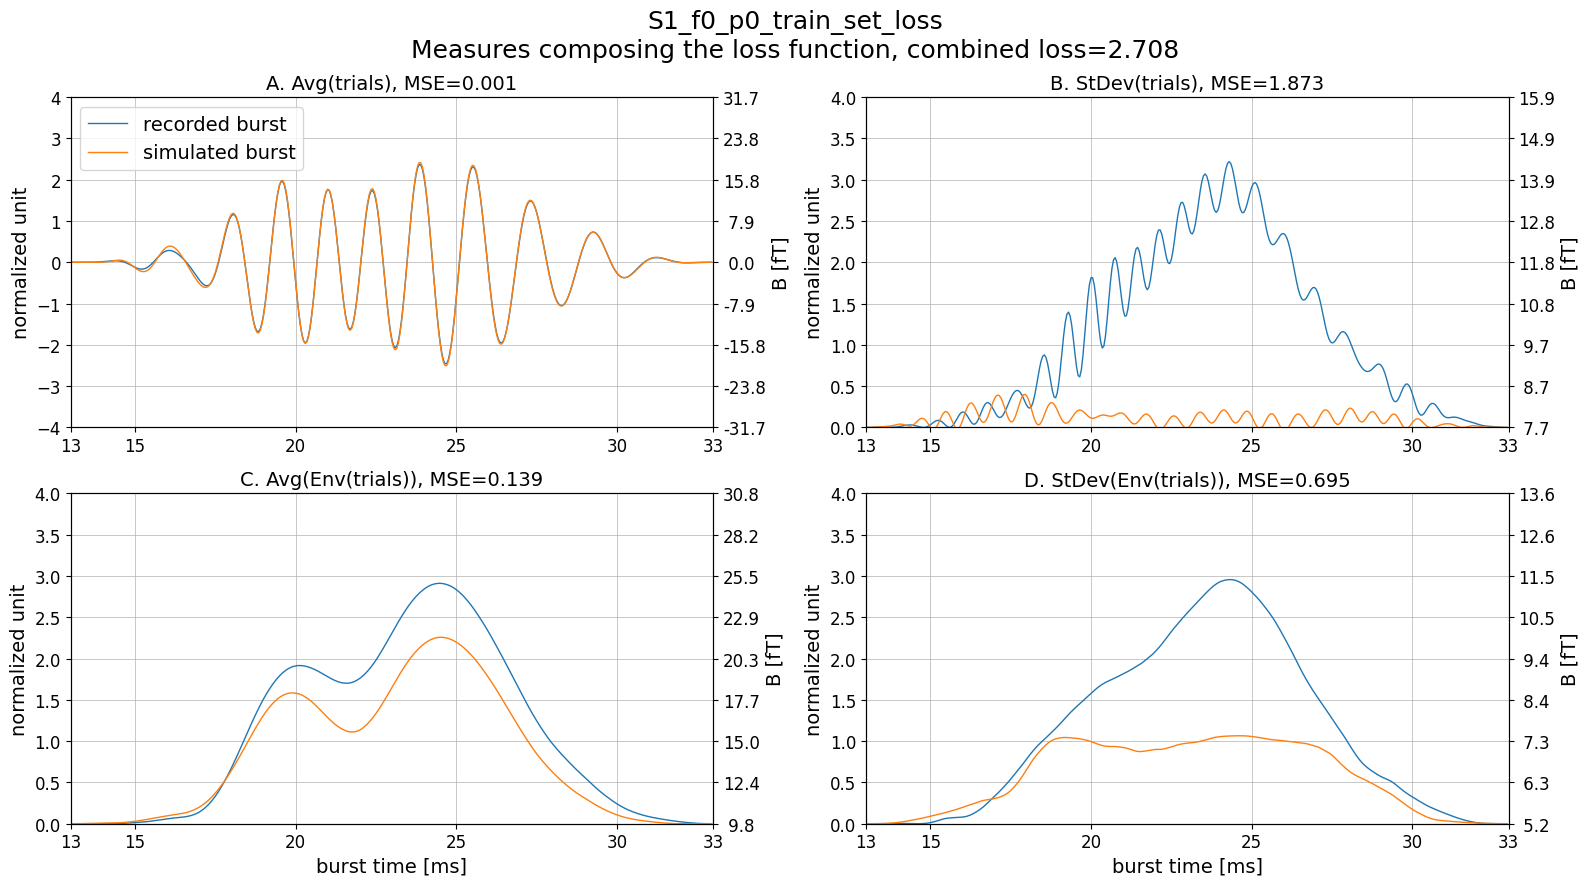

--------------------
f0/S1_f0_p0_test_set_loss.png


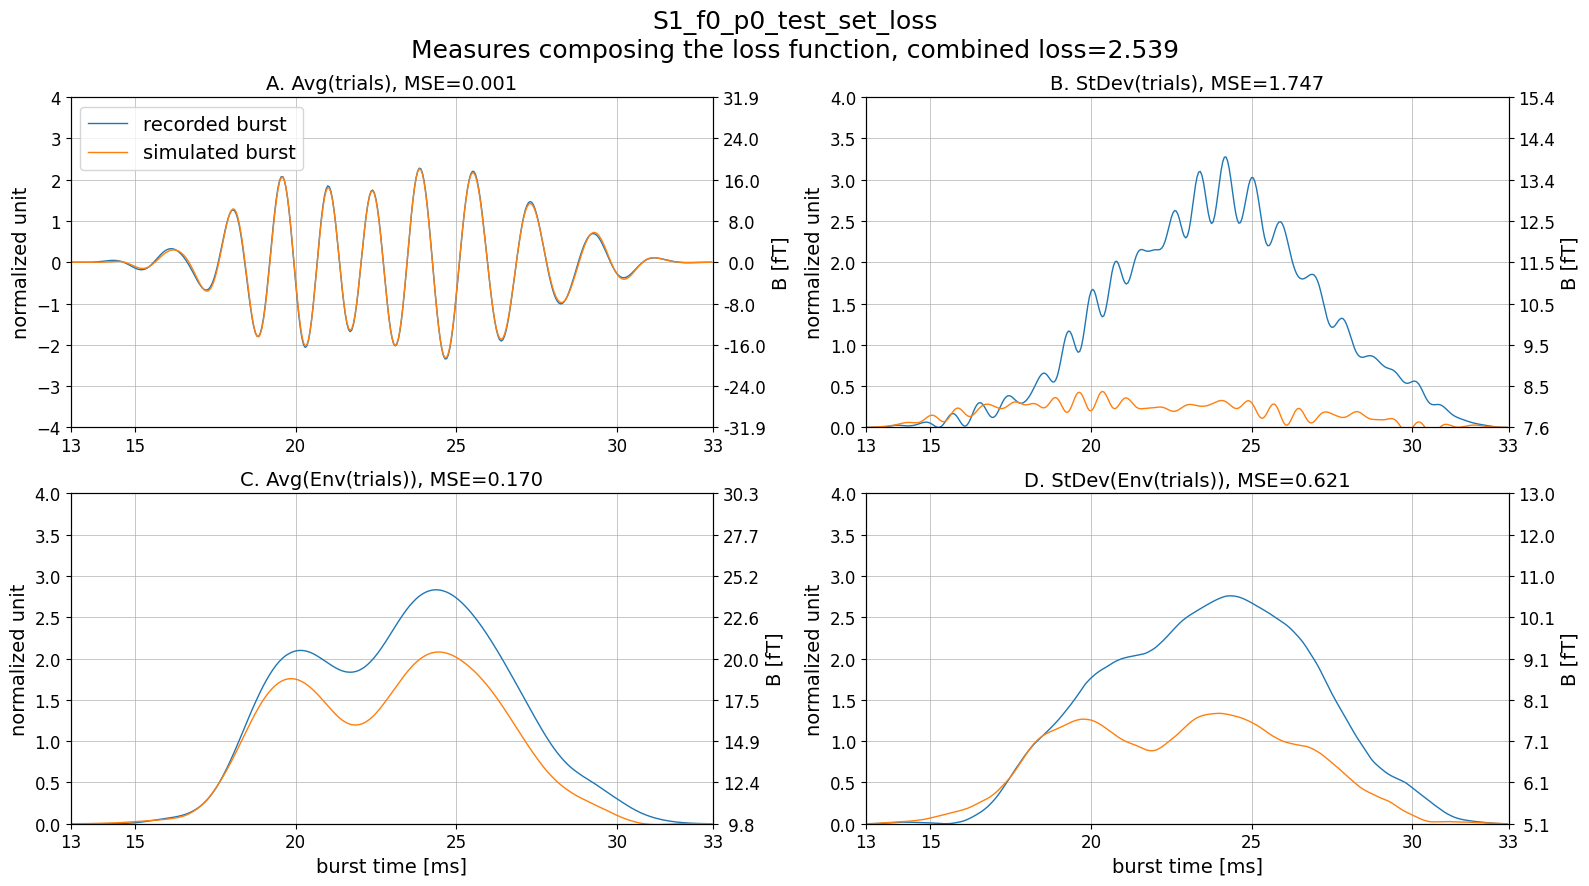

2.538607090626713
run: 0, iter : 0
 fun: 0.6694554947920031
   x: [ 1.000e+01  4.222e-11  7.253e-11  9.766e-12  3.413e-01  3.982e+00]
run: 0, iter : 1
 fun: 0.517361147014611
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.553e-01  3.722e+00]
run: 0, iter : 2
 fun: 0.34601770705648244
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.625e-01  3.415e+00]
run: 0, iter : 3
 fun: 0.26341035907261806
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.733e-01  3.067e+00]
run: 0, iter : 4
 fun: 0.2550339547471985
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.867e-01  2.924e+00]
run: 0, iter : 5
 fun: 0.254557449351596
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.903e-01  2.882e+00]
run: 0, iter : 6
 fun: 0.25455558909339143
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.904e-01  2.880e+00]
run: 0, iter : 7
 fun: 0.2545555633466535
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.905e-01  2.880e+00]
run: 0, iter : 8
 fun: 0.25455556274520386
   x: [ 1.

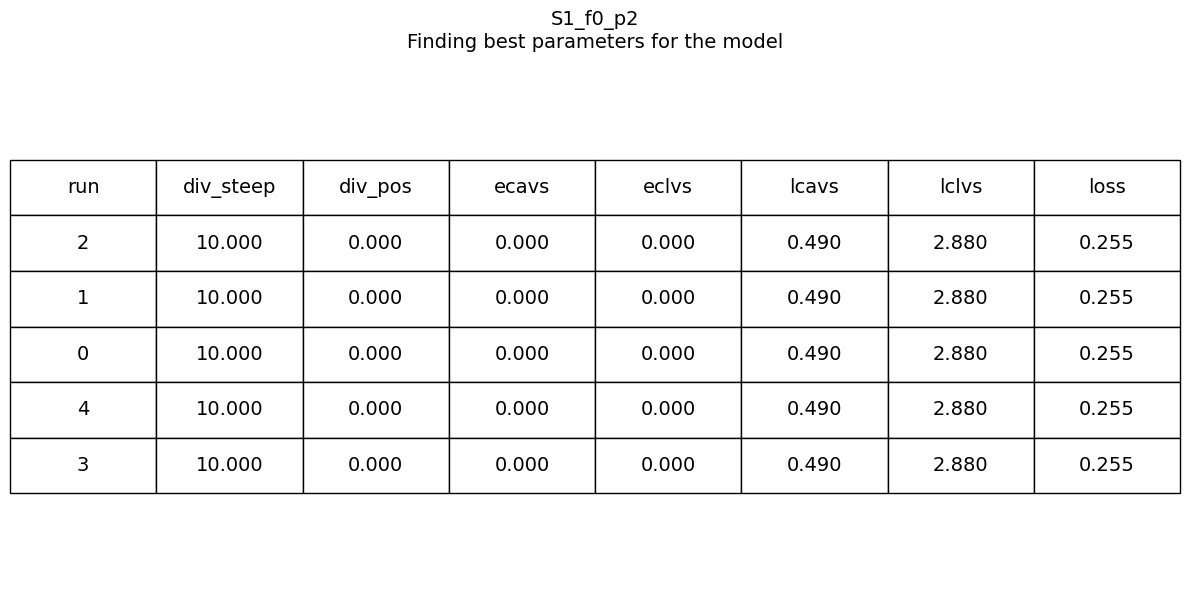

--------------------
f0/S1_f0_p2_runs_curves.png


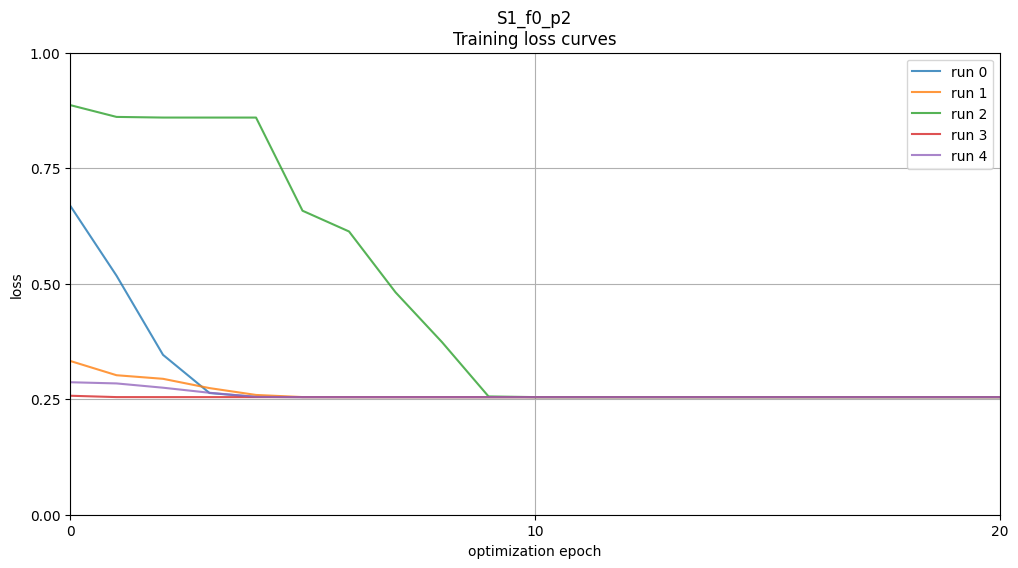

[1.00000000e+01 0.00000000e+00 1.00000000e-10 1.00000000e-10
 4.90470808e-01 2.87961117e+00]
0.2545555622053811
--------------------
f0/S1_f0_p2_div_curve.png


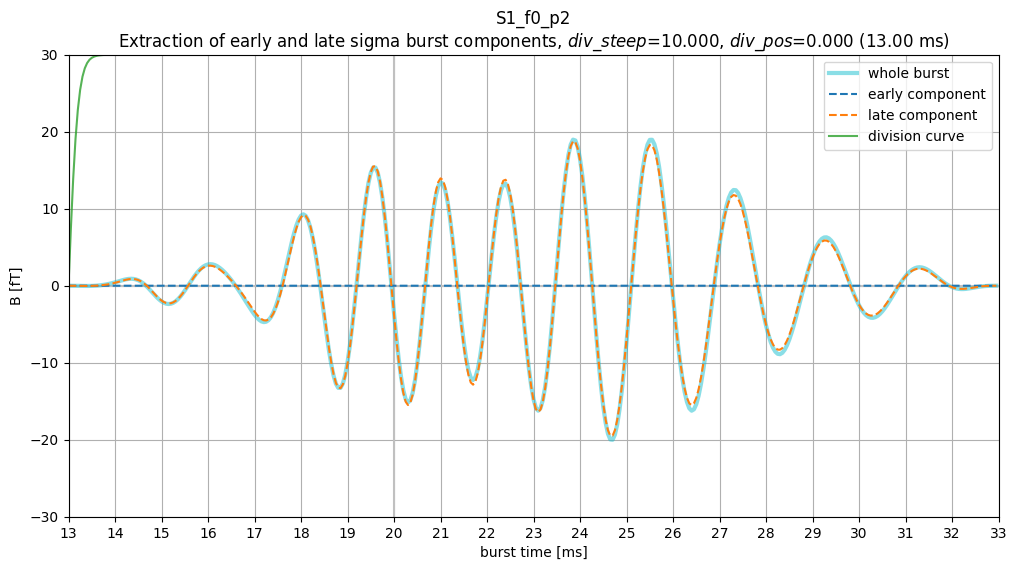

--------------------
f0/S1_f0_p2_train_set_loss.png


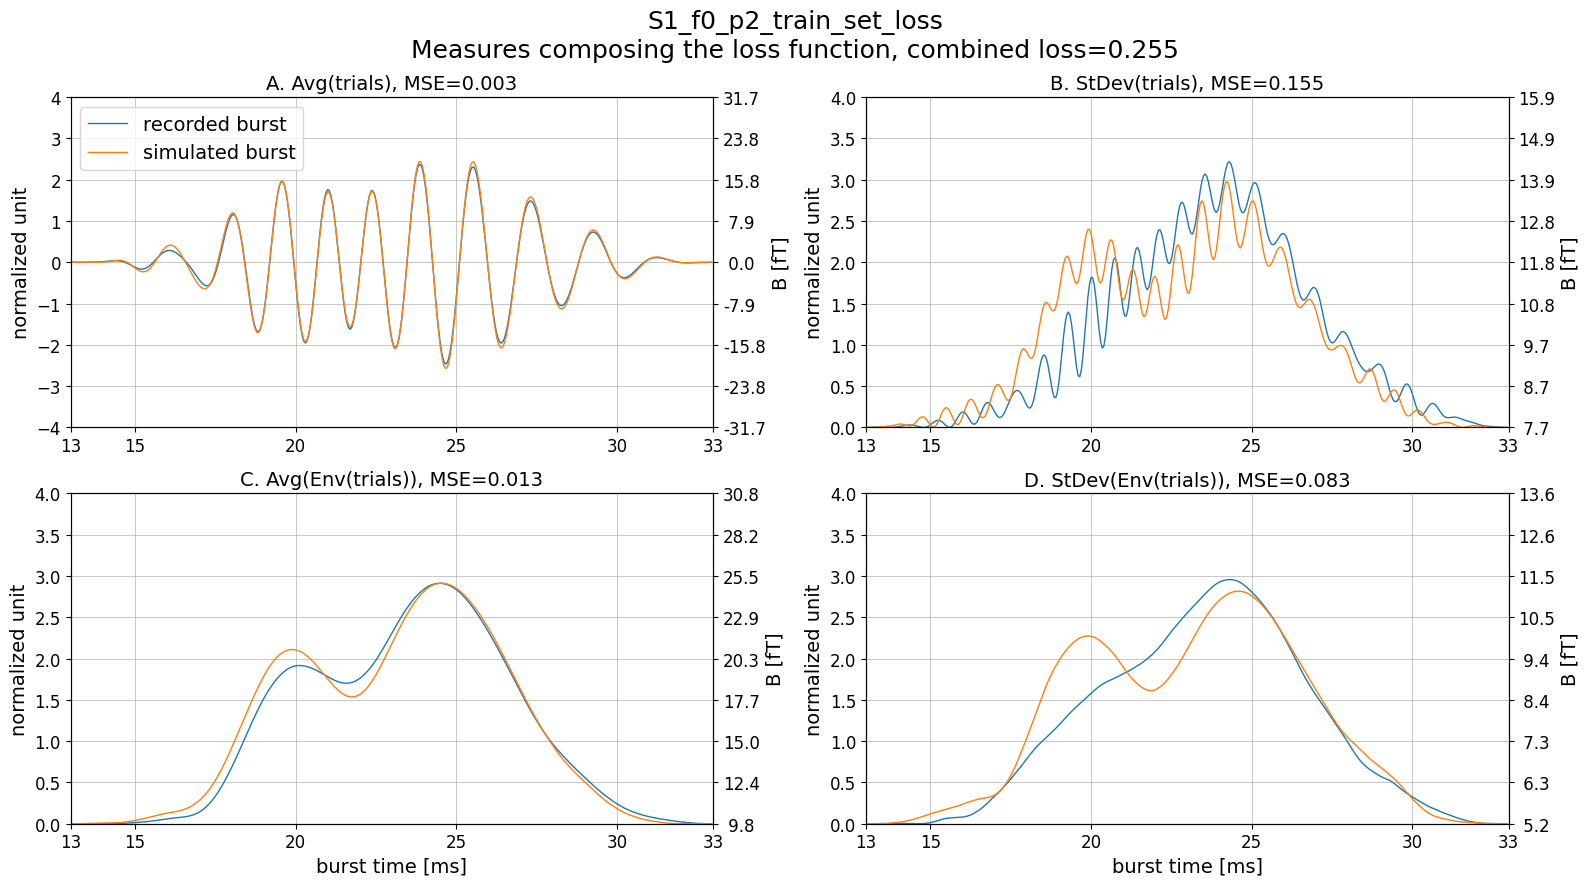

--------------------
f0/S1_f0_p2_test_set_loss.png


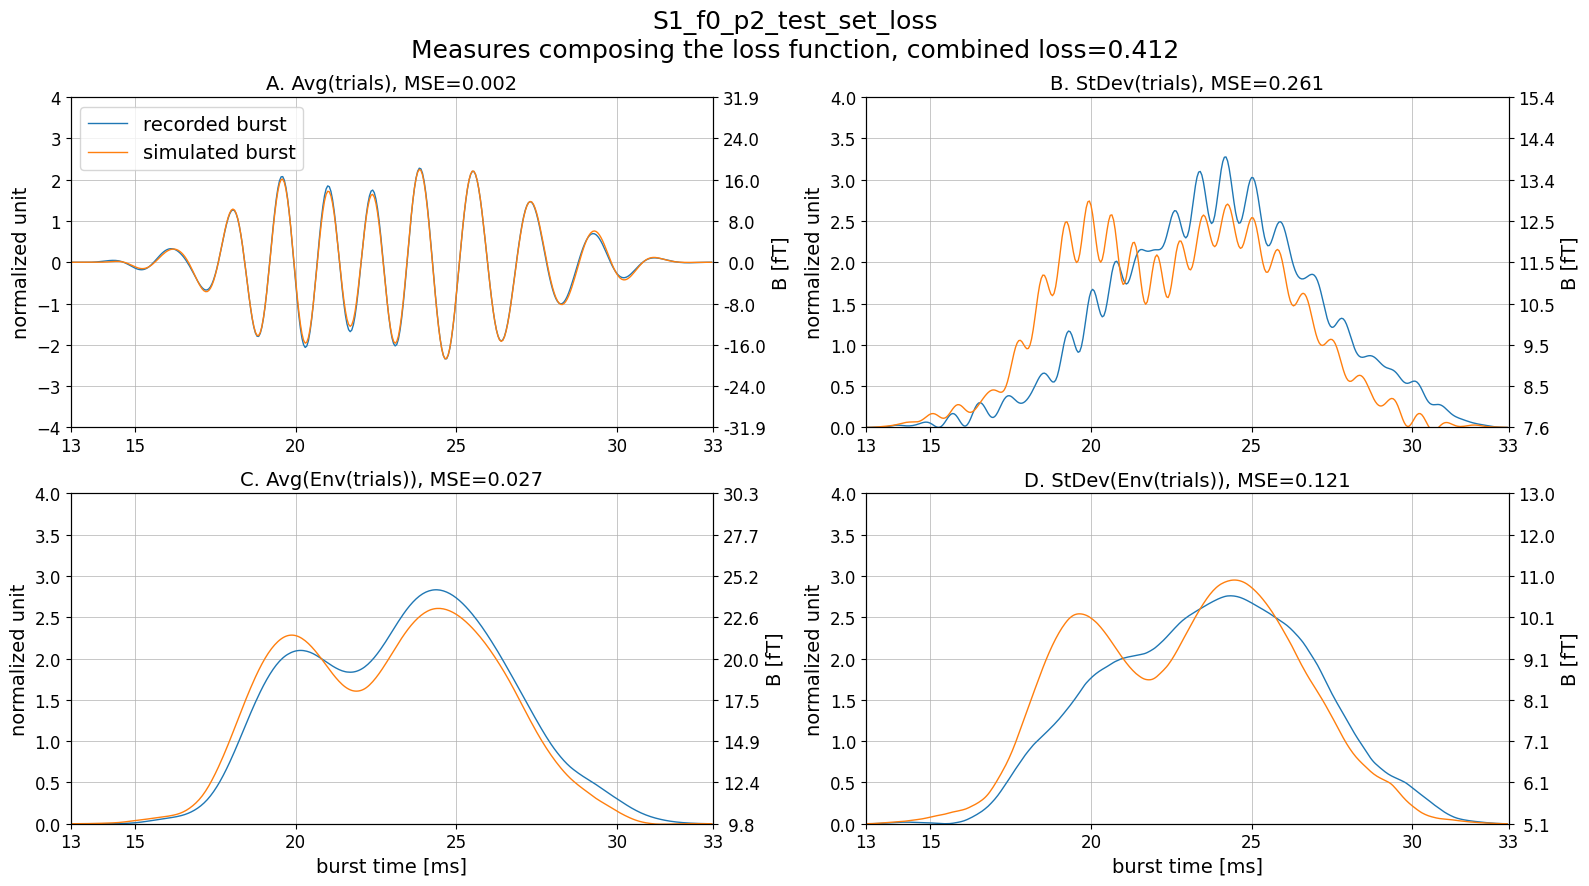

0.4118701753300064
run: 0, iter : 0
 fun: 0.4220982392489473
   x: [ 4.507e+00  3.023e-01  1.000e-10  9.090e-11  3.389e-01  2.869e+00]
run: 0, iter : 1
 fun: 0.20652544690803404
   x: [ 4.507e+00  2.950e-01  1.000e-10  8.503e-11  4.463e-01  2.915e+00]
run: 0, iter : 2
 fun: 0.12699616645463277
   x: [ 4.507e+00  3.275e-01  1.000e-10  1.000e-10  5.444e-01  2.950e+00]
run: 0, iter : 3
 fun: 0.1262235146661595
   x: [ 4.506e+00  3.518e-01  1.000e-10  0.000e+00  5.432e-01  2.950e+00]
run: 0, iter : 4
 fun: 0.12150133748402284
   x: [ 4.507e+00  3.388e-01  1.000e-10  0.000e+00  5.355e-01  2.948e+00]
run: 0, iter : 5
 fun: 0.1214013679152355
   x: [ 4.506e+00  3.380e-01  1.000e-10  0.000e+00  5.362e-01  2.950e+00]
run: 0, iter : 6
 fun: 0.12125054131567567
   x: [ 4.506e+00  3.370e-01  1.000e-10  0.000e+00  5.361e-01  2.953e+00]
run: 0, iter : 7
 fun: 0.1208787579064732
   x: [ 4.505e+00  3.358e-01  1.000e-10  0.000e+00  5.354e-01  2.965e+00]
run: 0, iter : 8
 fun: 0.1201000549344617
   x: [

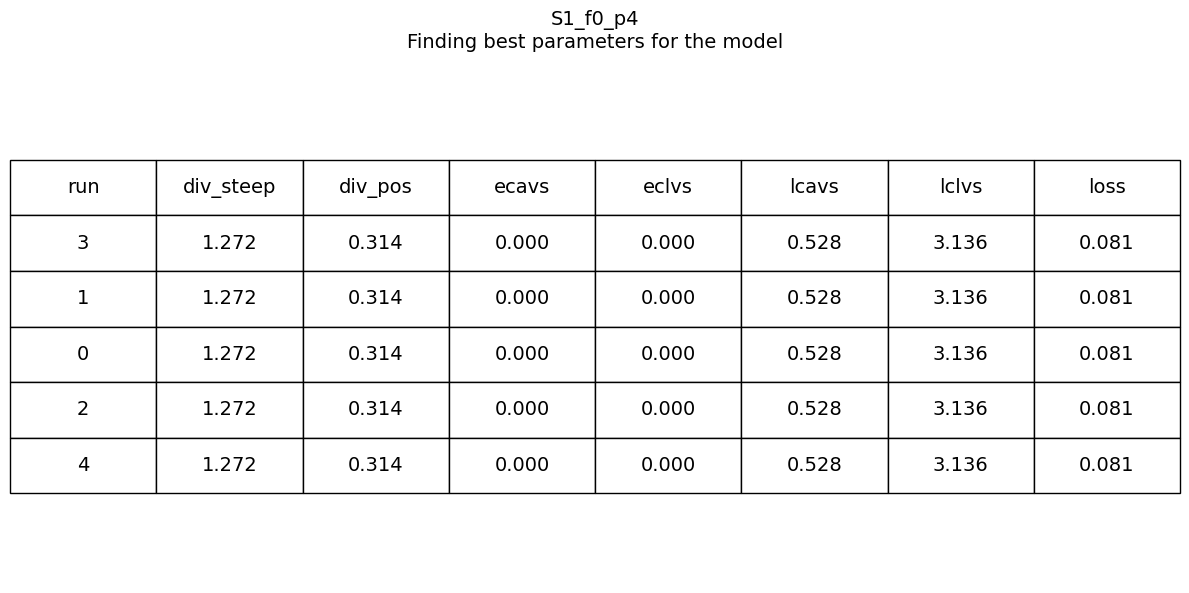

--------------------
f0/S1_f0_p4_runs_curves.png


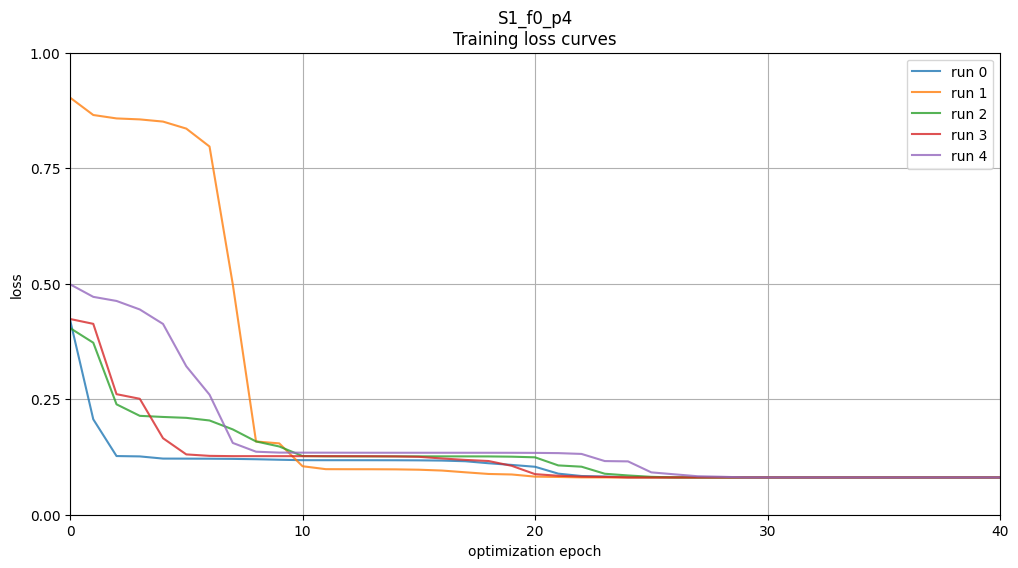

[1.27223590e+00 3.13594970e-01 0.00000000e+00 1.00000000e-10
 5.28119001e-01 3.13551488e+00]
0.0806482558458565
--------------------
f0/S1_f0_p4_div_curve.png


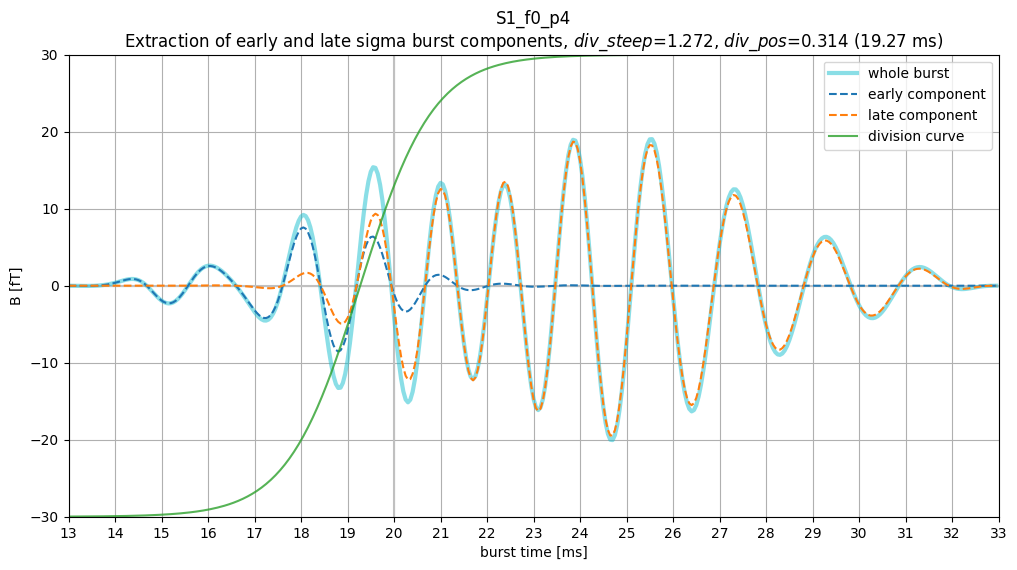

--------------------
f0/S1_f0_p4_train_set_loss.png


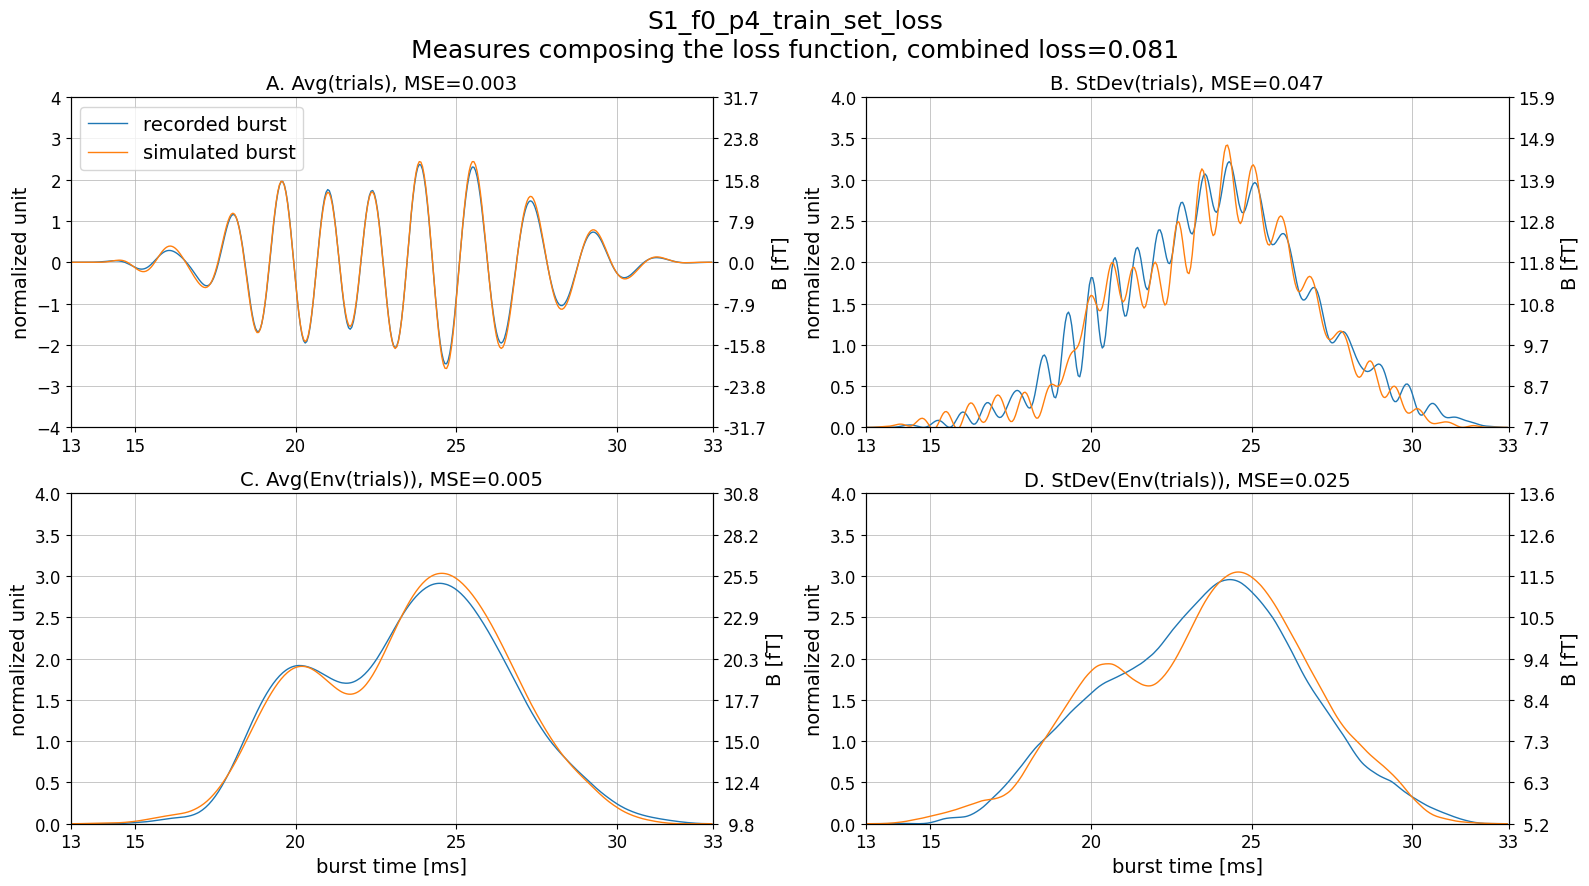

--------------------
f0/S1_f0_p4_test_set_loss.png


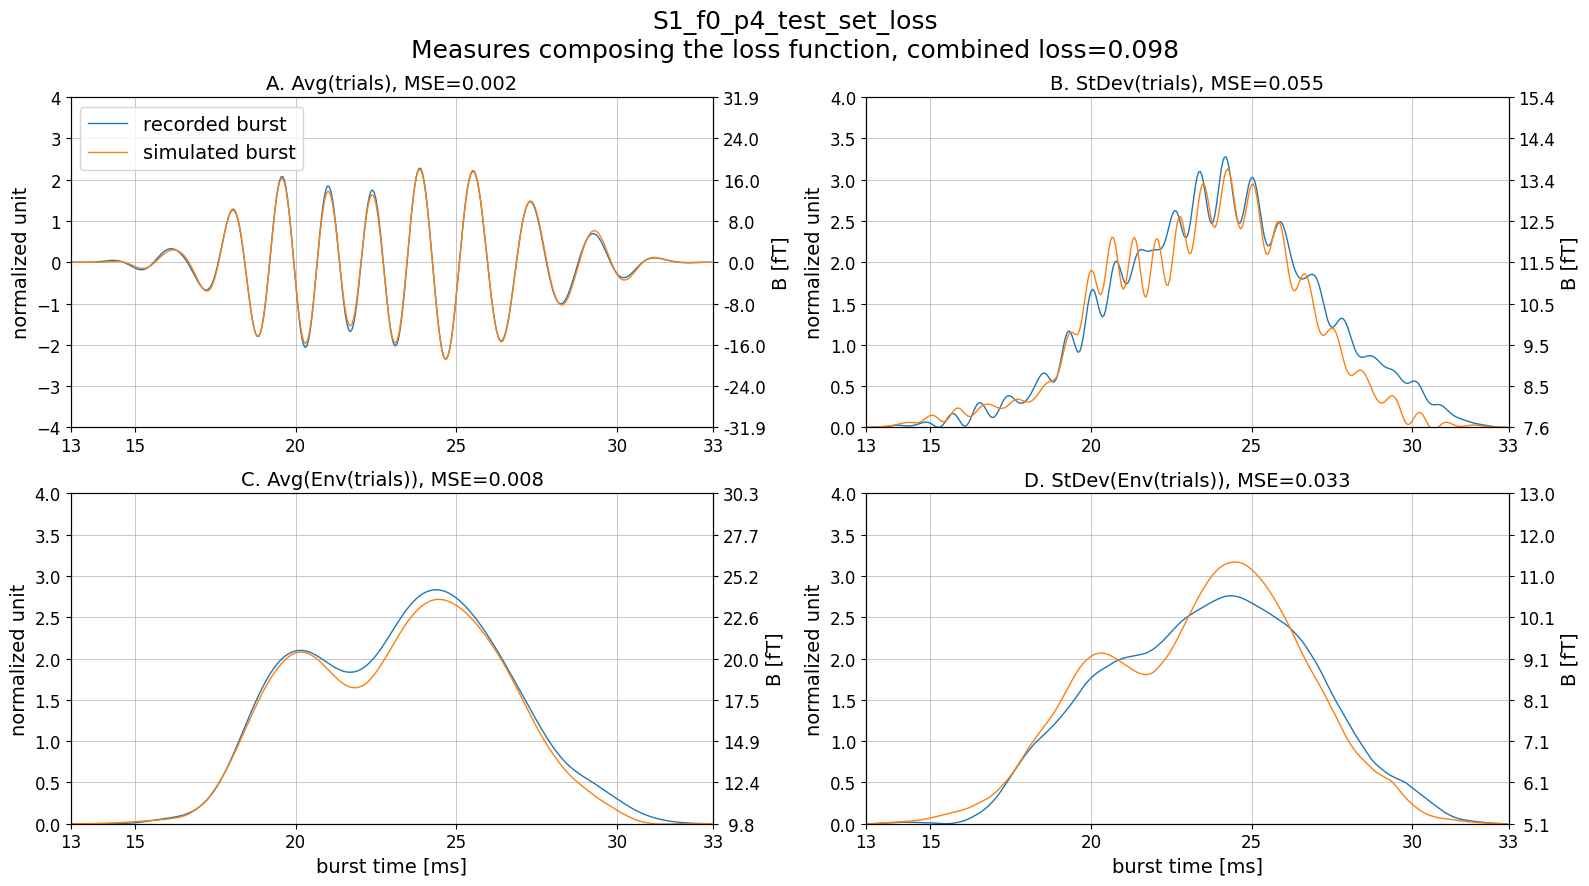

0.09839702450446838
run: 0, iter : 0
 fun: 0.2991081729323176
   x: [ 1.971e+00  3.248e-02  8.762e-01  2.953e+00  5.539e-01  2.464e+00]
run: 0, iter : 1
 fun: 0.2926224788672225
   x: [ 1.971e+00  3.266e-02  8.762e-01  2.953e+00  5.333e-01  2.468e+00]
run: 0, iter : 2
 fun: 0.29072270985478443
   x: [ 1.971e+00  3.287e-02  8.762e-01  2.953e+00  5.275e-01  2.478e+00]
run: 0, iter : 3
 fun: 0.2825662287834905
   x: [ 1.971e+00  3.412e-02  8.762e-01  2.953e+00  5.085e-01  2.543e+00]
run: 0, iter : 4
 fun: 0.2706225647441185
   x: [ 1.971e+00  3.644e-02  8.762e-01  2.953e+00  4.886e-01  2.666e+00]
run: 0, iter : 5
 fun: 0.25796434383308176
   x: [ 1.971e+00  4.057e-02  8.761e-01  2.953e+00  4.741e-01  2.858e+00]
run: 0, iter : 6
 fun: 0.2547579115247341
   x: [ 1.971e+00  4.413e-02  8.761e-01  2.953e+00  4.838e-01  2.892e+00]
run: 0, iter : 7
 fun: 0.2544343801773692
   x: [ 1.971e+00  4.524e-02  8.761e-01  2.953e+00  4.903e-01  2.881e+00]
run: 0, iter : 8
 fun: 0.25443268134712127
   x: [

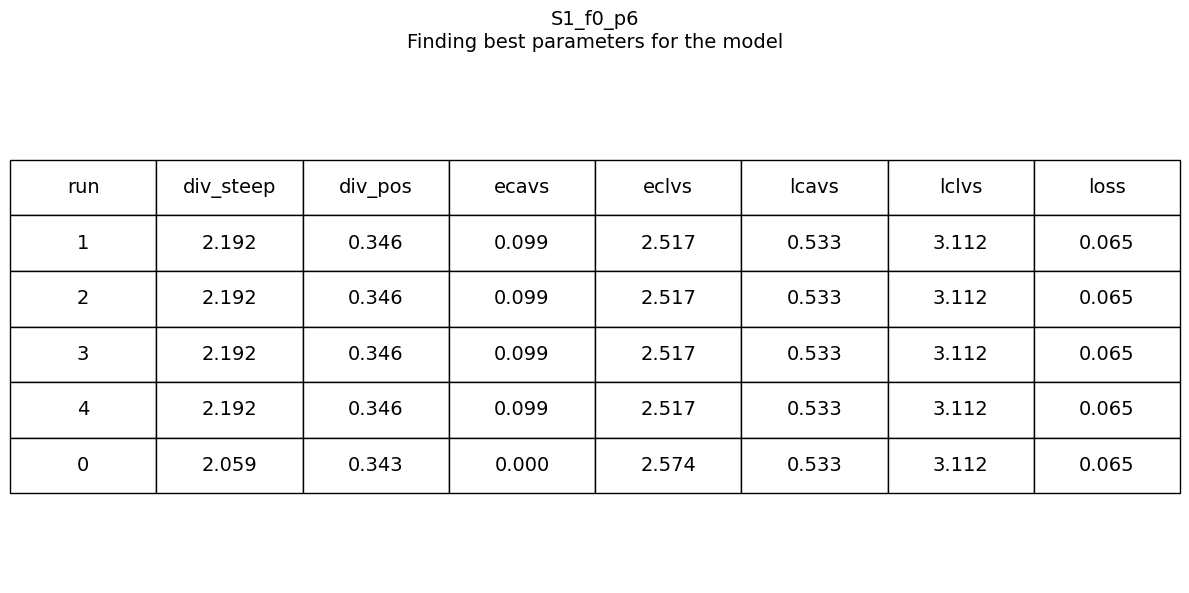

--------------------
f0/S1_f0_p6_runs_curves.png


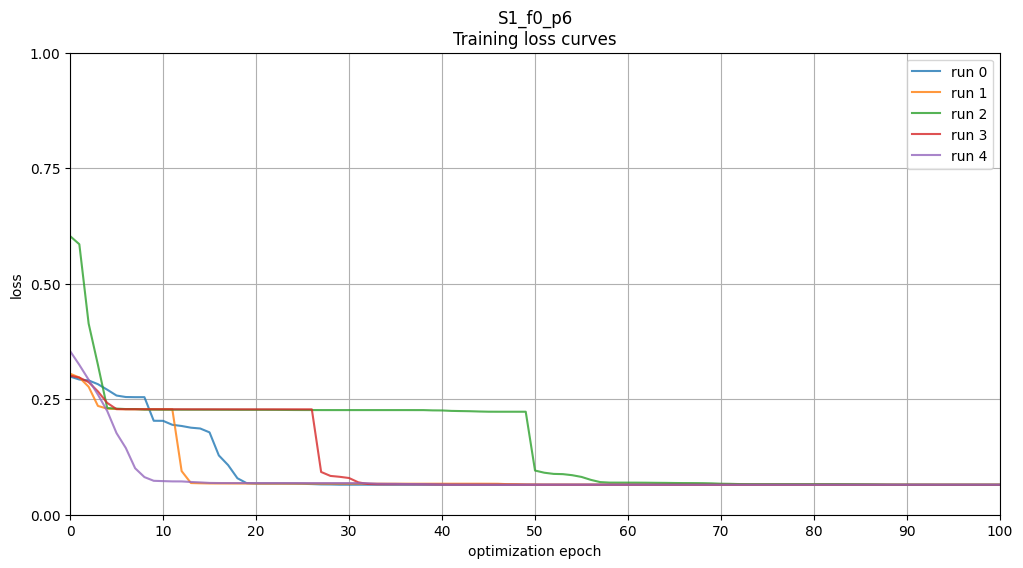

[2.19190212 0.34628513 0.09871668 2.51746553 0.53280969 3.11224873]
0.0648362924689147
--------------------
f0/S1_f0_p6_div_curve.png


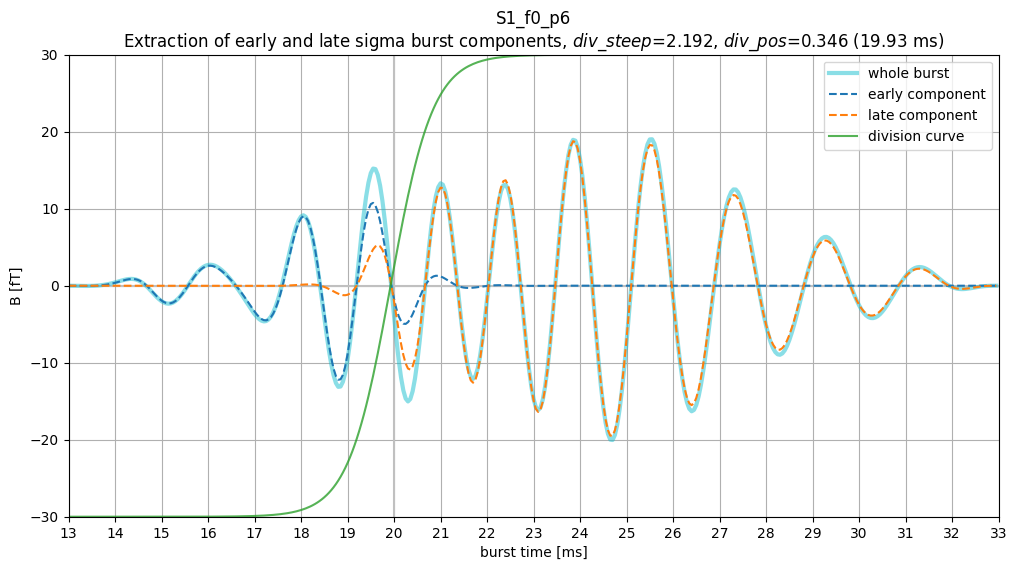

--------------------
f0/S1_f0_p6_train_set_loss.png


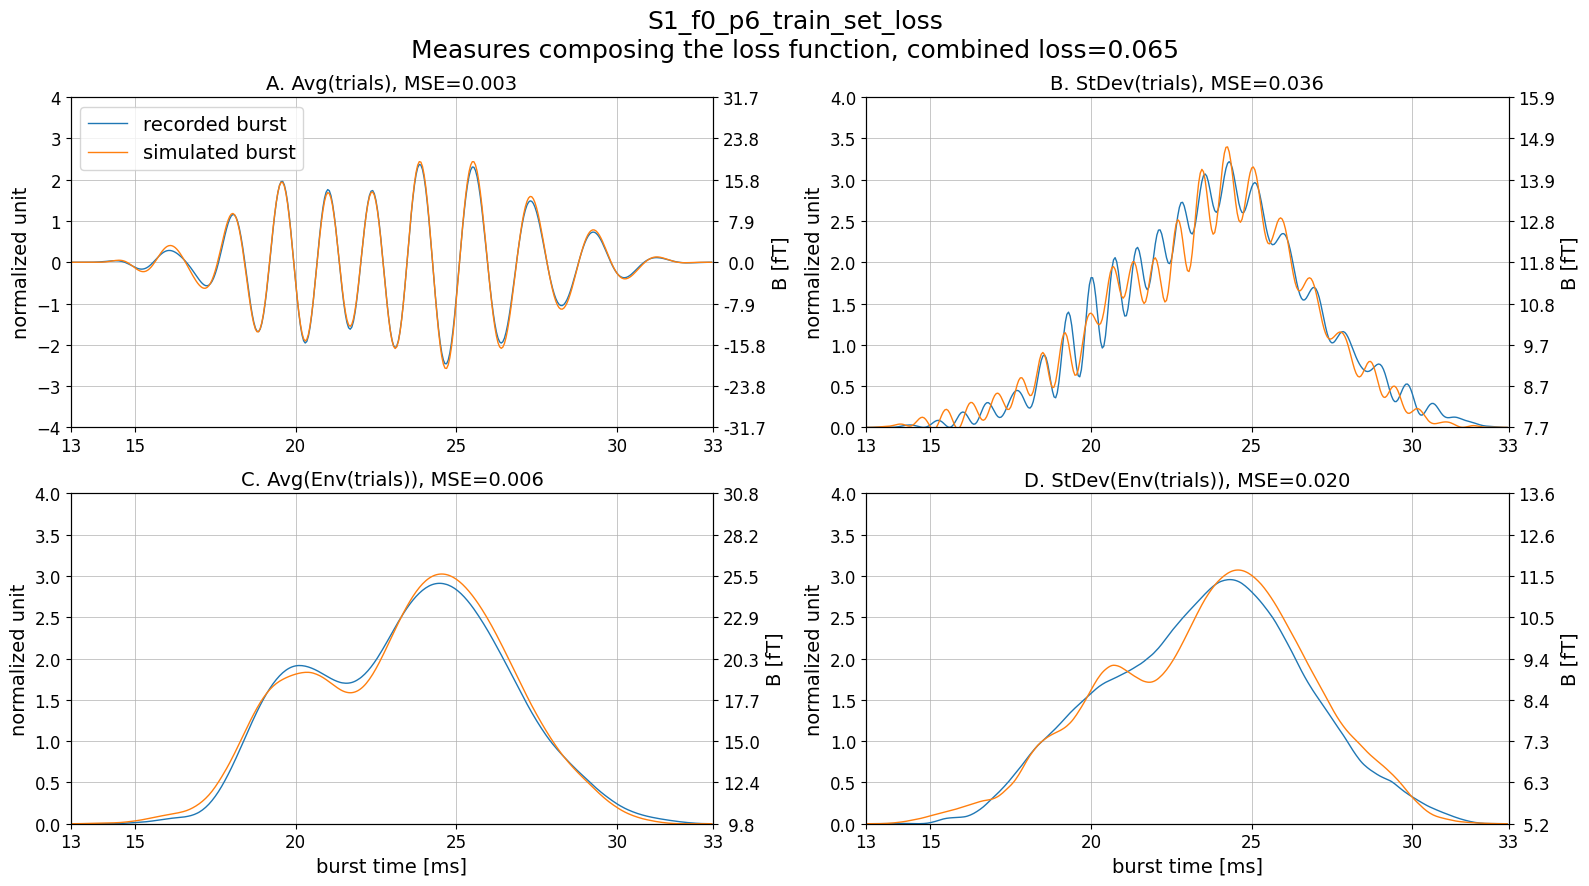

--------------------
f0/S1_f0_p6_test_set_loss.png


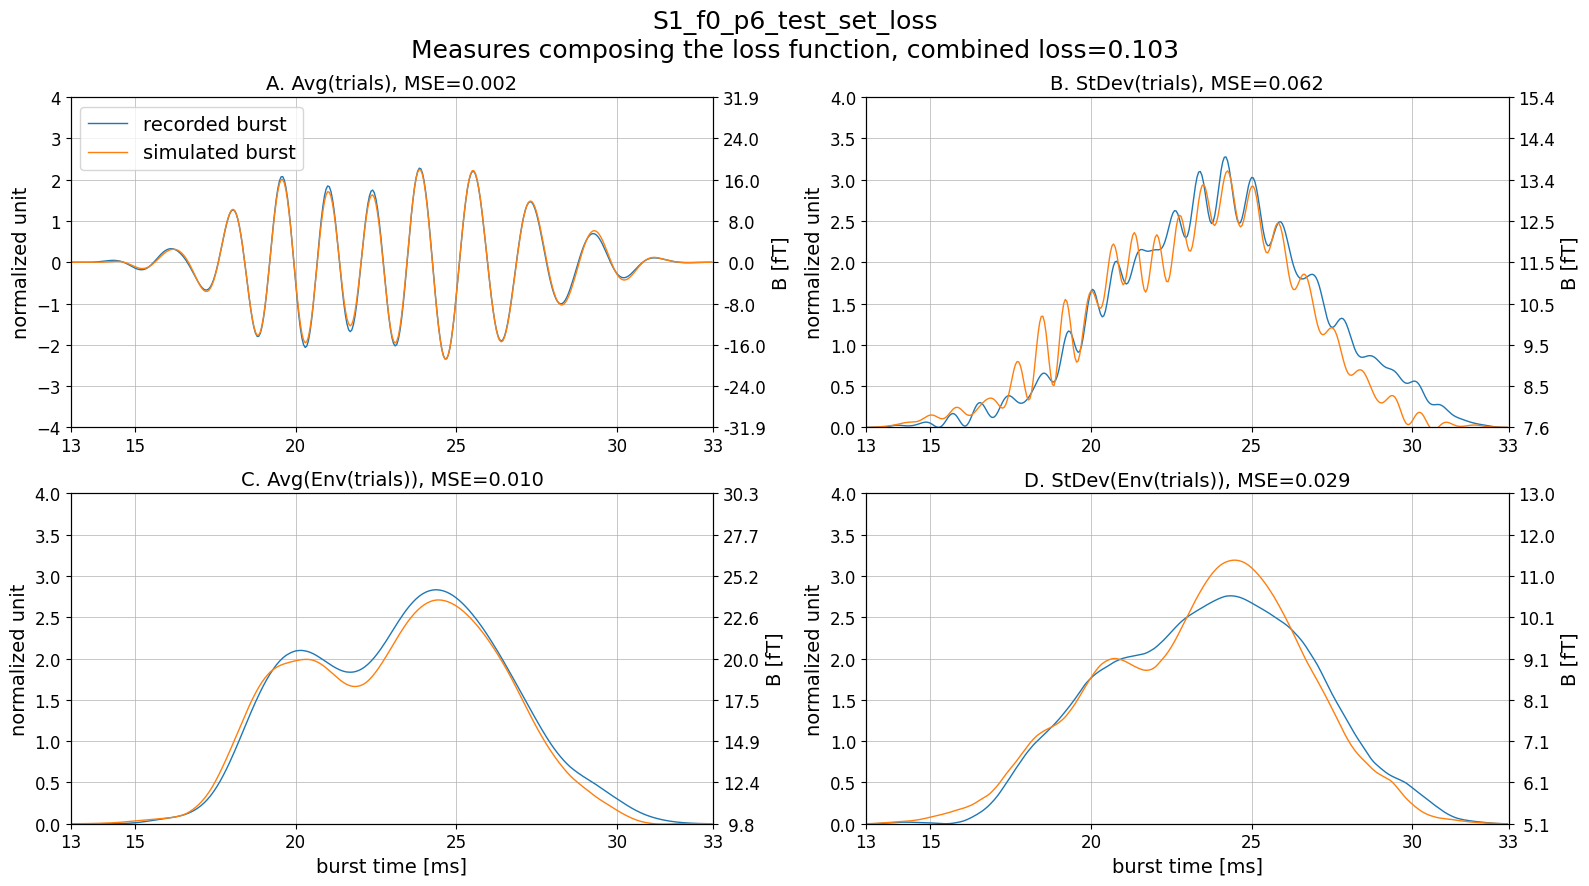

0.10344830415810008
(10, 0, 0, 0, 0, 0)
2.538607090626713
--------------------
f1/S1_f1_p0_div_curve.png


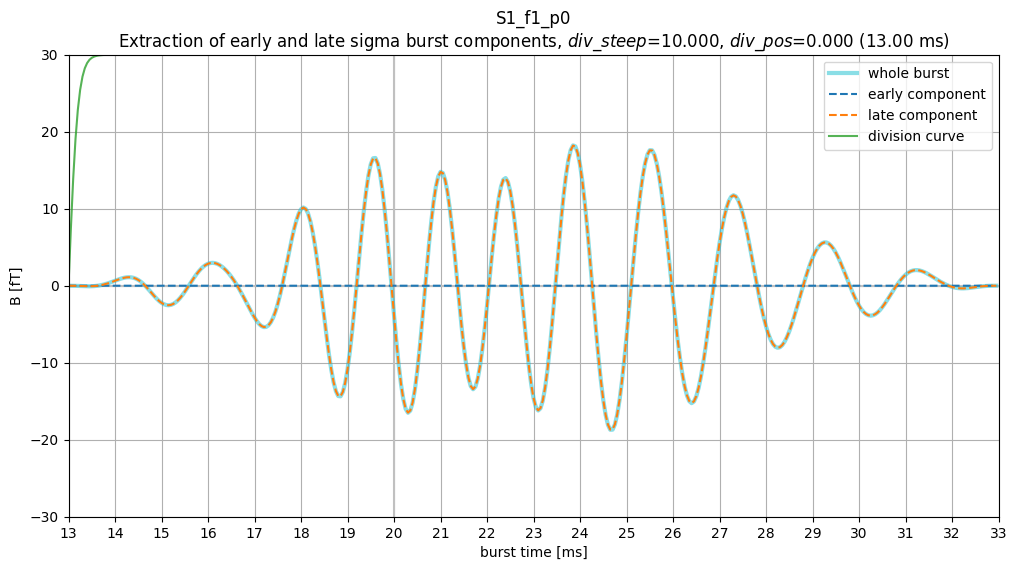

--------------------
f1/S1_f1_p0_train_set_loss.png


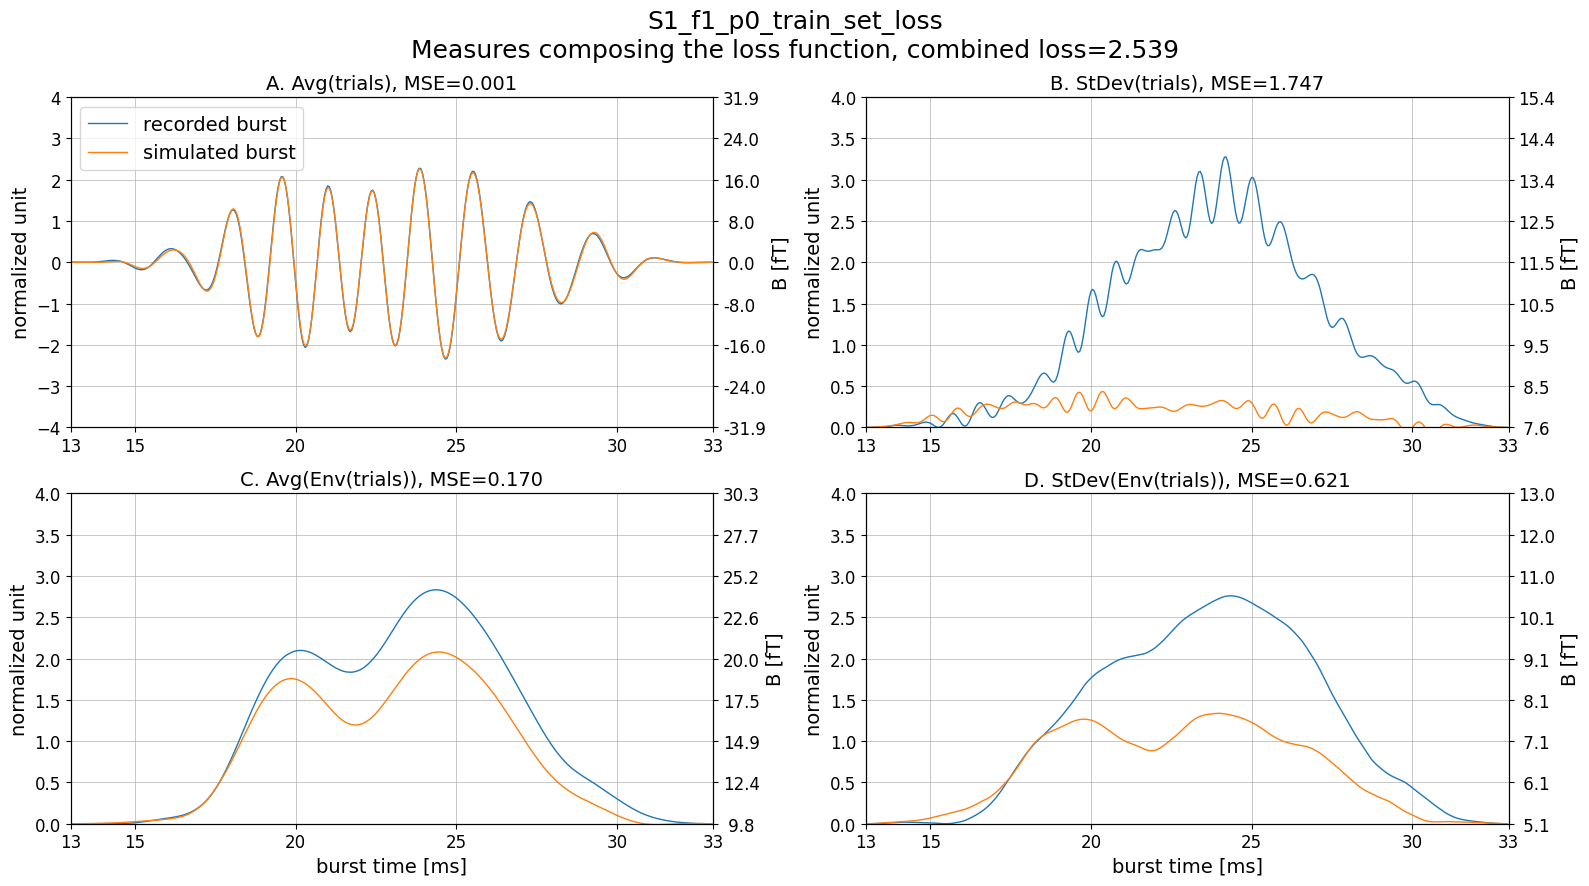

--------------------
f1/S1_f1_p0_test_set_loss.png


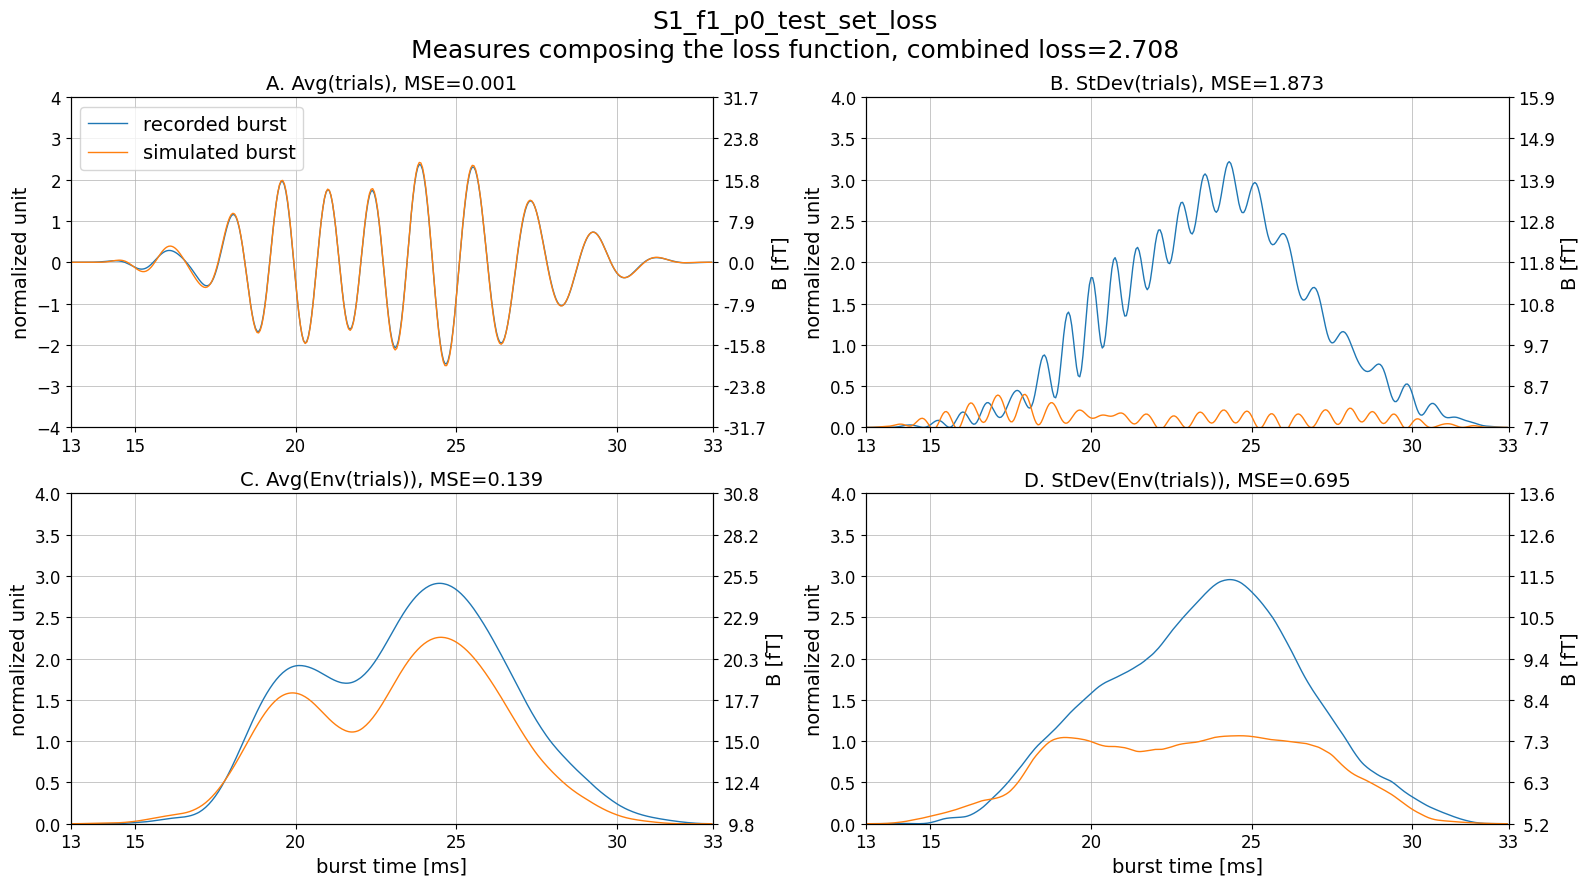

2.707575227085715
run: 0, iter : 0
 fun: 0.6552757395515459
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  5.876e-01  2.939e+00]
run: 0, iter : 1
 fun: 0.4738740451581267
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  3.641e-01  2.606e+00]
run: 0, iter : 2
 fun: 0.37599568793312266
   x: [ 1.000e+01  1.000e-10  7.253e-11  9.766e-12  4.391e-01  2.706e+00]
run: 0, iter : 3
 fun: 0.3727434405361598
   x: [ 1.000e+01  1.000e-10  7.253e-11  9.766e-12  4.594e-01  2.716e+00]
run: 0, iter : 4
 fun: 0.3726204880939416
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.574e-01  2.707e+00]
run: 0, iter : 5
 fun: 0.37260901842557553
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.578e-01  2.703e+00]
run: 0, iter : 6
 fun: 0.3726058972468548
   x: [ 1.000e+01  1.000e-10  7.253e-11  9.766e-12  4.585e-01  2.699e+00]
run: 0, iter : 7
 fun: 0.3726058309058411
   x: [ 1.000e+01  1.000e-10  7.253e-11  9.766e-12  4.585e-01  2.699e+00]
run: 0, iter : 8
 fun: 0.3726057824248249
   x: [ 1.

KeyboardInterrupt: 

In [16]:
# burst variability modeling

# make calculations for 10 train/test data subsets (folds)
for fold in range(10):

    # random seed for data split and models initialization
    # use twice the same random seed to generate the same data split
    rndm_seed=fold//2
    np.random.seed(rndm_seed)

    # generate two data subsets, A and B
    n_trials = sigma_medium_trials.shape[-1]
    set_A_samples = np.random.choice(n_trials, size=n_trials//2, replace=False)
    set_A_samples.sort()
    set_B_samples = np.setdiff1d(np.arange(n_trials), set_A_samples)

    # at first use the subset A for training and B for test
    # and than the subset B for training and A for test
    if(fold % 2 == 0):
        sigma_medium_trials_train = sigma_medium_trials[:,set_A_samples]
        sigma_medium_trials_test = sigma_medium_trials[:,set_B_samples]
    else:
        sigma_medium_trials_train = sigma_medium_trials[:,set_B_samples]
        sigma_medium_trials_test = sigma_medium_trials[:,set_A_samples]

    # if the number of trials is small, double the subsets
    # to get a better approximate Gaussian distribution of added variability
    if(n_trials < 1200):
        sigma_medium_trials_train = np.concatenate([sigma_medium_trials_train,
                                                    sigma_medium_trials_train], axis=1)
        sigma_medium_trials_test = np.concatenate([sigma_medium_trials_test,
                                                    sigma_medium_trials_test], axis=1)

    # make directory to save the output 
    os.makedirs(os.path.join(results_output_folder, 'f'+str(fold)+'/'), exist_ok=True)

    # 4 increasing complexity models
    for m_cmplx in range(4):

        fig_title_base = subject+'_f'+str(fold)+'_p'+str(m_cmplx*2)
        fig_name_base = 'f'+str(fold)+'/'+fig_title_base

        # burst model for training subset
        bm_train = BurstModel(data_t_medium_ms, sigma_medium_trials_train,
                            burst_win_ms, sigma_sim_offset_ms, srate, rndm_seed+100)

        # burst model for test subset
        bm_test = BurstModel(data_t_medium_ms, sigma_medium_trials_test,
                            burst_win_ms, sigma_sim_offset_ms, srate, rndm_seed+200)

        eps=1e-10

        if(m_cmplx == 0):
            # no variability
            model_variables = (10, 0, 0, 0, 0, 0)
        else:
            if(m_cmplx == 1):
                # amplitude and latency variability
                bnds = scipy.optimize.Bounds(lb=(10, 0, 0, 0, 0, 0), ub=(10+eps, eps, eps, eps, 2, 5))
                maxfun = 500
            elif(m_cmplx == 2):
                # split and variability of later component
                bnds = scipy.optimize.Bounds(lb=(0.5, 0, 0, 0, 0, 0), ub=(10, 1, eps, eps, 2, 5))
                maxfun = 1000
            elif(m_cmplx == 3):
                # split and variability of both components
                bnds = scipy.optimize.Bounds(lb=(0.5, 0, 0, 0, 0, 0), ub=(10, 1, 1, 3, 2, 5))
                maxfun = 2000


            runs_loss_curves = []
            runs_loss_temp = []
            runs_loss_fin = []
            runs_params_fin = []

            n_runs = 5   # number of performed runs
            opt_run = 0  # optimization runs counter
            opt_iter = 0 # optimization internal iterations counter

            def opt_callback(intermediate_result):

                global opt_iter
                runs_loss_temp.append(intermediate_result['fun'])
                print('run: %d, iter : %d' % (opt_run, opt_iter))
                print(intermediate_result)
                opt_iter += 1

            # run optimization n_runs times
            for opt_run in range(n_runs):

                opt_iter = 0
                runs_loss_temp = []

                minimizer_kwargs = {'method':'L-BFGS-B', 'bounds':bnds, 'callback':opt_callback}
                opt_results = scipy.optimize.dual_annealing(lambda arg : bm_train.calculate_model_output(arg)[0],
                                                bounds=bnds, maxfun=maxfun, minimizer_kwargs=minimizer_kwargs)

                runs_loss_curves.append(runs_loss_temp)
                runs_params_fin.append(opt_results.x)
                runs_loss_fin.append(opt_results.fun)

            max_epochs = np.max([len(k) for k in runs_loss_curves])
            max_epochs = np.ceil(max_epochs/20)*20
            max_epochs = int(max_epochs)


            # convert lists to arrays
            # if early stopping was applied
            # extend them to the length of max_epochs
            for i in range(len(runs_loss_curves)):
                arr = runs_loss_curves[i]
                arr = np.array(arr)
                arr = np.concatenate((arr, (np.ones(max_epochs+1-len(arr))*arr[-1])))
                runs_loss_curves[i] = arr

            runs_loss_curves = np.array(runs_loss_curves)
            runs_loss_fin = np.array(runs_loss_fin)
            runs_params_fin = np.array(runs_params_fin)


            # plot output as a table
            table_data = np.concatenate(([np.arange(len(runs_params_fin))], runs_params_fin.T, [runs_loss_fin])).T
            table_data = table_data[table_data[:, -1].argsort()]
            table_data = np.array([["{:.3f}".format(value) for value in row] for row in table_data])
            for i in range(len(table_data[:,0])): table_data[:,0][i] = table_data[:,0][i].split('.')[0]
            table_labels = ['run', 'div_steep', 'div_pos', 'ecavs', 'eclvs', 'lcavs', 'lclvs', 'loss']

            fig, ax = plt.subplots()
            plt.suptitle(fig_title_base+'\nFinding best parameters for the model', fontsize=14)
            table = ax.table(cellText=table_data, colLabels=table_labels, loc='center', cellLoc='center')
            table.set_fontsize(15)
            table.scale(1, 3)
            ax.axis('off')
            fig.tight_layout()
            plt_show_save_fig(fig_name_base+'_runs_table')


            # plot training curves
            fig, ax = plt.subplots()
            plt.title(fig_title_base+'\nTraining loss curves')
            y_max=np.ceil(np.max(runs_loss_curves))
            ax.plot(runs_loss_curves.T, alpha=0.8)
            ax.set_xlim(0, max_epochs)
            ax.set_ylim(0.0, y_max)
            ax.set_xlabel('optimization epoch')
            ax.set_ylabel('loss')
            ax.xaxis.set_major_locator(plticker.MultipleLocator(10))
            ax.yaxis.set_major_locator(plticker.MultipleLocator(0.25))
            ax.grid(visible=True)
            ax.legend([f"run {i}" for i in range(len(runs_loss_curves))])
            plt_show_save_fig(fig_name_base+'_runs_curves')

            # take parameters from the best run
            model_variables = runs_params_fin[runs_loss_fin.argmin()]

        [div_steep, div_pos, ecavs, eclvs, lcavs, lclvs] = model_variables
        div_pos_ms = div_pos*(burst_win_ms[1]-burst_win_ms[0])+burst_win_ms[0]

        [result, division_curve, late_comp_sigma_er, lcabs, early_comp_sigma_er, ecabs, sigma_bursts_sim,
        sigma_sim_medium_trials] = [i.numpy() for i in bm_train.calculate_model_output(model_variables)]

        train_loss = result
        print(model_variables)
        print(train_loss)

        # plot extracted components
        fig, ax = plt.subplots()
        plt.title(fig_title_base+'\nExtraction of early and late sigma burst components, ' \
        '$\it{div\_steep}$=%.3f, $\it{div\_pos}$=%.3f (%.2f ms)' % (div_steep, div_pos, div_pos_ms))

        ax.axhline(0, color='silver')
        ax.axvline(20, color='silver')
        ax.plot(data_t_burst_ms, sigma_bursts_sim.real.mean(-1), label='whole burst',
                linewidth=3, alpha=0.5, c='tab:cyan')
        ax.plot(data_t_burst_ms, early_comp_sigma_er.real, label='early component', linestyle='--')
        ax.plot(data_t_burst_ms, late_comp_sigma_er.real, label='late component', linestyle='--')
        division_curve_rescaled = 30*(2*division_curve-1)
        ax.plot(data_t_medium_ms, division_curve_rescaled, alpha=0.8, label='division curve')

        ax.set_xlabel('burst time [ms]')
        ax.set_ylabel(meg_unit)
        vmax=30
        ax.set_ylim((-vmax,vmax))
        ax.set_xlim((burst_win_ms[0], burst_win_ms[-1]))
        ax.xaxis.set_major_locator(plticker.MultipleLocator(1))
        ax.grid(visible=True)
        ax.legend()

        plt_show_save_fig(fig_name_base+'_div_curve')

        plot_loss_results(bm_train, sigma_sim_medium_trials,
                        filename=fig_name_base+'_train_set_loss')

        [result, division_curve, late_comp_sigma_er, lcabs, early_comp_sigma_er, ecabs, sigma_bursts_sim,
        sigma_sim_medium_trials] = [i.numpy() for i in bm_test.calculate_model_output(model_variables)]


        plot_loss_results(bm_test, sigma_sim_medium_trials,
                        filename=fig_name_base+'_test_set_loss')

        test_loss = result
        print(test_loss)

        new_out_record = [subject, fold, m_cmplx*2, div_steep, div_pos,
                        ecavs, eclvs, lcavs, lclvs, train_loss, test_loss]
        df_out.loc[len(df_out)] = new_out_record

In [ ]:
# show optimization results
df_out

In [ ]:
# save optimization results to a file
df_out.to_csv(os.path.join(results_output_folder, subject+'_results.csv'), index=False)